<a href="https://colab.research.google.com/github/A-kki/DS/blob/main/Akshay_CI1_Image_Classification_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial : Covid 19 Prediction using Artificial Neural Networks

Dataset: [Covid 19 Chest X-ray dataset](https://www.kaggle.com/tawsifurrahman/covid19-radiography-database)


A team of researchers from Qatar University, Doha, Qatar, and the University of Dhaka, Bangladesh along with their collaborators from Pakistan and Malaysia in collaboration with medical doctors have created a database of chest X-ray images for COVID-19 positive cases along with Normal and Viral Pneumonia images. This COVID-19, normal, and other lung infection dataset is released in stages. In the first release, we have released 219 COVID-19, 1341 normal, and 1345 viral pneumonia chest X-ray (CXR) images. In the first update, we have increased the COVID-19 class to 1200 CXR images. In the 2nd update, we have increased the database to 3616 COVID-19 positive cases along with 10,192 Normal, 6012 Lung Opacity (Non-COVID lung infection), and 1345 Viral Pneumonia images. We will continue to update this database as soon as we have new x-ray images for COVID-19 pneumonia patients.



**1. Mount the Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Move to the place where data resides**

In [5]:
%cd "/content/drive/MyDrive/Colab Notebooks/covid_dataset"

/content/drive/MyDrive/Colab Notebooks/covid_dataset


In [6]:
!ls

covid_dataset


**3. Unziping the dataset**

In [7]:
!pip install unzip

  Preparing metadata (setup.py) ... done
  Created wheel for unzip: filename=unzip-1.0.0-py3-none-any.whl size=1281 sha256=56a8f780dc6f8bc71e59db0f6035f2499db80674cbfdf3fb271fa485de4b8b41
  Stored in directory: /root/.cache/pip/wheels/fb/5b/81/0f3e1e533b52883f88ab978178c15627a4fce4c13f74911dce
Successfully built unzip


In [10]:
!unzip "/content/drive/MyDrive/Colab Notebooks/covid_dataset.zip" -d "/content/covid_data"


Archive:  /content/drive/MyDrive/Colab Notebooks/covid_dataset.zip
   creating: /content/covid_data/covid_dataset/
   creating: /content/covid_data/covid_dataset/COVID/
  inflating: /content/covid_data/covid_dataset/COVID/COVID-1.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-10.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-11.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-12.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-13.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-14.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-15.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-16.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-17.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-18.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-19.png  
  inflating: /content/covid_data/covid_dataset/COVID/COVID-2.png  
  inflating: /con

**4. Install split folder python package**

https://pypi.org/project/split-folders/

In [11]:
!pip install split_folders

**5. Splitting the data in training, testing and validation set**

In [12]:
import splitfolders
splitfolders.ratio("covid_dataset", output="split", seed=1337, ratio=(.8, .1, .1), group_prefix=None)

Copying files: 150 files [01:39,  1.50 files/s]


**6. Loading the dataset with normalization in batches**

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize training and validation data in the range of 0 to 1
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, # Rotate images by up to 20 degrees
    width_shift_range=0.2, # Shift images horizontally by up to 20%
    height_shift_range=0.2, # Shift images vertically by up to 20%
    shear_range=0.2, # Shear transformations
    zoom_range=0.2, # Zoom in on images
    horizontal_flip=True, # Allow horizontal flipping
    fill_mode='nearest' # Fill new pixels created by transformations
)
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Read the training sample and set the batch size
train_generator = train_datagen.flow_from_directory(
        'split/train/',
        target_size=(128, 128),
        batch_size=8,
        seed=100,
        class_mode='categorical')

# Read Validation data from directory and define target size with batch size
validation_generator = validation_datagen.flow_from_directory(
        'split/val/',
        target_size=(128, 128),
        batch_size=8,
        class_mode='categorical',
        seed=1000,
        shuffle=False)

test_generator = test_datagen.flow_from_directory(
        'split/test/',
        target_size=(128, 128),
        batch_size=8,
        seed=500,
        class_mode='categorical',
        shuffle=False)

Found 120 images belonging to 3 classes.
Found 15 images belonging to 3 classes.
Found 15 images belonging to 3 classes.


**7. Model Building**

In [34]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Load the MobileNetV2 model pre-trained on ImageNet, without its top classification layer
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')

# Freeze the pre-trained layers so they are not updated during training
for layer in base_model.layers:
    layer.trainable = False

# Add a custom classification head on top of the base model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x) # Global Average Pooling to reduce dimensionality
x = layers.Dense(256, activation='relu')(x) # Additional Dense layer for feature learning
x = layers.Dropout(0.5)(x) # Dropout for regularization
outputs = layers.Dense(3, activation='softmax')(x) # Output layer for 3 classes

model = Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 328,707 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

**8. Model Compilation and Training**

In [35]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

model_checkpoint = ModelCheckpoint(
    'best_covid_classification_model.h5', # Path to save the model
    monitor='val_accuracy', # Monitor validation accuracy
    save_best_only=True, # Save only the best model
    mode='max', # Maximize validation accuracy
    verbose=1
)

# Adjusted learning rate for potentially better convergence
adam = Adam(learning_rate=0.0001) # Slightly reduced learning rate for fine-tuning

# We are going to use accuracy metrics and cross entropy loss as performance parameters
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with callbacks
history = model.fit(
      train_generator,
      steps_per_epoch=int(train_generator.samples / train_generator.batch_size),
      epochs=100, # Increased epochs as EarlyStopping will manage actual training length
      validation_data=validation_generator,
      validation_steps=int(validation_generator.samples / validation_generator.batch_size),
      callbacks=[early_stopping, model_checkpoint],
      verbose=1)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4042 - loss: 1.6625
Epoch 1: val_accuracy improved from None to 0.25000, saving model to best_covid_classification_model.h5



Epoch 1: finished saving model to best_covid_classification_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 550ms/step - accuracy: 0.4083 - loss: 1.5256 - val_accuracy: 0.2500 - val_loss: 1.1384
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4517 - loss: 1.4930
Epoch 2: val_accuracy improved from 0.25000 to 0.37500, saving model to best_covid_classification_model.h5



Epoch 2: finished saving model to best_covid_classification_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - accuracy: 0.4667 - loss: 1.4047 - val_accuracy: 0.3750 - val_loss: 1.0680
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5905 - loss: 0.9111
Epoch 3: val_accuracy improved from 0.37500 to 0.62500, saving model to best_covid_classification_model.h5



Epoch 3: finished saving model to best_covid_classification_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - accuracy: 0.5750 - loss: 0.9935 - val_accuracy: 0.6250 - val_loss: 0.8874
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.4097 - loss: 1.4355
Epoch 4: val_accuracy improved from 0.62500 to 0.75000, saving model to best_covid_classification_model.h5



Epoch 4: finished saving model to best_covid_classification_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 162ms/step - accuracy: 0.5167 - loss: 1.2178 - val_accuracy: 0.7500 - val_loss: 0.8117
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.5781 - loss: 0.9834
Epoch 5: val_accuracy did not improve from 0.75000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5667 - loss: 0.9886 - val_accuracy: 0.7500 - val_loss: 0.7546
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7046 - loss: 0.8141
Epoch 6: val_accuracy did not improve from 0.75000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.6833 - loss: 0.8745 - val_accuracy: 0.7500 - val_loss: 0.7208
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.6868 - loss: 0.8248
Epoch 7: val_accuracy did not improve from 0.75000
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.6750 - loss: 0.7851 - val_accuracy: 0.7500 - val_loss: 0.6963
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - 


Epoch 8: finished saving model to best_covid_classification_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - accuracy: 0.7250 - loss: 0.6916 - val_accuracy: 0.8750 - val_loss: 0.5752
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7138 - loss: 0.7069
Epoch 9: val_accuracy did not improve from 0.87500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6833 - loss: 0.7251 - val_accuracy: 0.7500 - val_loss: 0.6172
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7188 - loss: 0.7295
Epoch 10: val_accuracy did not improve from 0.87500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7333 - loss: 0.7243 - val_accuracy: 0.7500 - val_loss: 0.6418
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.6959 - loss: 0.6906
Epoch 11: val_accuracy did not improve from 0.87500
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7500 - loss: 0.6397 - val_accuracy: 0.7500 - val_loss: 0.5899
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/st

**9. Model saving**

In [16]:
model.save('covid_classification.h5')

**10. Model loading**

In [17]:
from tensorflow.keras import models
model = models.load_model('covid_classification.h5')

**11. Model weights saving**

In [18]:
model.save_weights('covid_classification_weights.weights.h5')

**12. Model weights loading**

In [19]:
model.load_weights('covid_classification_weights.weights.h5')

**13. Plotting accuracy and loss graph for training and validation dataset**

In [20]:
train_acc = history.history['accuracy'] # Change 'acc' to 'accuracy'
val_acc = history.history['val_accuracy'] # Change 'val_acc' to 'val_accuracy'
train_loss = history.history['loss']
val_loss = history.history['val_loss']

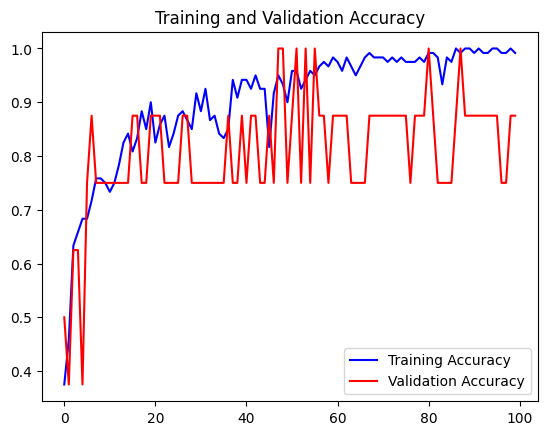

<Figure size 640x480 with 0 Axes>

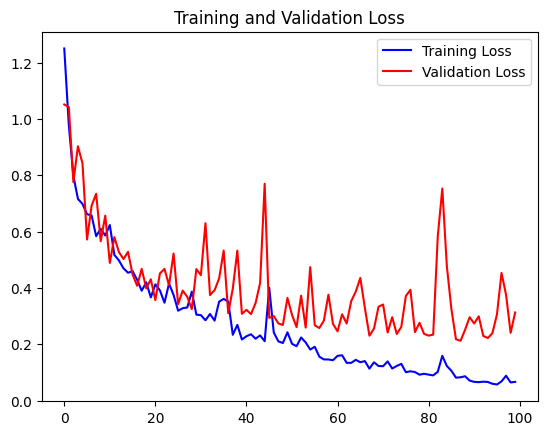

In [21]:
import matplotlib.pyplot as plt
epochs = range(len(train_acc))
plt.plot(epochs, train_acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.figure()
plt.show()

plt.plot(epochs, train_loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


**14. Evaluate model performance on test dataset**

In [36]:
test_output = model.evaluate(
    test_generator,
    steps=int(test_generator.samples / test_generator.batch_size),  # Convert steps to an integer
    verbose=1
)
print(test_output)
print(model.metrics_names)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.7500 - loss: 0.5340
[0.5340434312820435, 0.75]
['loss', 'compile_metrics']


References:

1. https://pypi.org/project/split-folders/
2. https://keras.io/